# Equity Portfolio Backtesting in R

## Contrarian and momentum strategies across ten technology stocks

This educational backtest simulates a **$5 million portfolio** during 2018. It compares two stock-selection rules—buying the five largest recent decliners and buying the five largest recent gainers—while tracking daily mark-to-market value, inferred dividends, benchmark performance, currency effects, and rebalancing frequency.

**Project context:** Originally completed as a graduate Data Analytics with R group project at New Jersey Institute of Technology. Team members were Steven Meyer, Matthew Pennington, and Theo Edgehill. My contributions primarily involved data cleaning, visualization, and formatting the final HTML submission. See the repository README for assumptions, limitations, and reproduction instructions.


### Data preparation

In [2]:
library(dplyr)
library(tidyr)  # Load tidyr to use replace_na()
library(ggplot2)
library(reshape2)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [3]:
### Load the data to dataframes

ibm_data = read.csv("data/raw/ibm.csv")
msft_data = read.csv("data/raw/msft.csv")
goog_data = read.csv("data/raw/goog.csv")
aapl_data = read.csv("data/raw/aapl.csv")
amzn_data = read.csv("data/raw/amzn.csv")
meta_data = read.csv("data/raw/meta.csv")
nflx_data = read.csv("data/raw/nflx.csv")
tsla_data = read.csv("data/raw/tsla.csv")
orcl_data = read.csv("data/raw/orcl.csv")
sap_data = read.csv("data/raw/sap.csv")


In [4]:
# List of all your dataframes
stocks_list = list(
  IBM = ibm_data,
  MSFT = msft_data,
  GOOG = goog_data,
  AAPL = aapl_data,
  AMZN = amzn_data,
  META = meta_data,
  NFLX = nflx_data,
  TSLA = tsla_data,
  ORCL = orcl_data,
  SAP = sap_data
)

In [5]:
# Apply renaming and selection
stocks_list = lapply(names(stocks_list), function(name) {
  df = stocks_list[[name]]
  df %>%
    select(Date, Close, `Adj.Close`) %>%
    rename(!!paste0(name, "_Close") := Close, !!paste0(name, "_Adj.Close") := `Adj.Close`)
})

In [6]:
universe = Reduce(function(x, y) merge(x, y, by = "Date", all = TRUE), stocks_list)
head(universe)

,Date,IBM_Close,IBM_Adj.Close,MSFT_Close,MSFT_Adj.Close,GOOG_Close,GOOG_Adj.Close,AAPL_Close,AAPL_Adj.Close,AMZN_Close,⋯,META_Close,META_Adj.Close,NFLX_Close,NFLX_Adj.Close,TSLA_Close,TSLA_Adj.Close,ORCL_Close,ORCL_Adj.Close,SAP_Close,SAP_Adj.Close
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1-Aug-18,137.19,102.14,106.28,99.56,61.00,60.85,50.38,47.83,89.86,⋯,171.65,171.13,338.38,338.38,20.06,20.06,47.35,43.02,115.95,104.70
2,1-Feb-18,155.26,113.21,94.26,87.51,58.38,58.24,41.94,39.51,69.50,⋯,193.09,192.51,265.07,265.07,23.28,23.28,51.63,46.54,111.65,99.30
3,1-Jun-18,135.71,101.04,100.79,94.42,55.97,55.84,47.56,45.16,82.08,⋯,193.99,193.41,359.93,359.93,19.45,19.45,47.35,42.85,113.73,102.70
4,1-Mar-18,147.05,108.28,92.85,86.60,53.48,53.34,43.75,41.38,74.67,⋯,175.94,175.41,290.39,290.39,22.06,22.06,49.71,44.80,102.00,90.72
5,1-May-18,138.62,102.08,95.00,88.61,51.87,51.74,42.28,39.99,79.11,⋯,173.86,173.34,313.30,313.30,19.99,19.99,45.95,41.59,111.72,99.36
6,1-Nov-18,111.69,84.06,105.92,99.60,53.50,53.37,55.56,52.94,83.28,⋯,151.75,151.29,317.38,317.38,22.95,22.95,48.59,44.33,106.67,96.32


In [7]:
clean_and_prepare_data = function(df) {
  # Convert Date column from character to Date format
  df$Date = as.Date(df$Date, format = "%d-%b-%y")

  # Step 2: Create a continuous sequence of dates
  full_dates = data.frame(Date = seq(min(df$Date), max(df$Date), by = "day"))

  # Step 3: Merge the original dataframe with the full sequence of dates
  df = merge(full_dates, df, by = "Date", all.x = TRUE)

  return(df)
}

In [8]:
# You will create a dataframe where there are 20 columns for the 10 stocks, each row is the "Close" and "Adj Close" prices for the 10 stocks on each day, in the order of the business days in 2018. 
# Assume all buy/sell on the "Close" prices and there is no transaction cost.
universe = clean_and_prepare_data(universe)
head(universe)

,Date,IBM_Close,IBM_Adj.Close,MSFT_Close,MSFT_Adj.Close,GOOG_Close,GOOG_Adj.Close,AAPL_Close,AAPL_Adj.Close,AMZN_Close,⋯,META_Close,META_Adj.Close,NFLX_Close,NFLX_Adj.Close,TSLA_Close,TSLA_Adj.Close,ORCL_Close,ORCL_Adj.Close,SAP_Close,SAP_Adj.Close
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.47,107.53,85.95,79.79,53.25,53.12,43.06,40.57,59.45,⋯,181.42,180.88,201.07,201.07,21.37,21.37,46.63,41.87,112.39,99.96
2,2018-01-03,151.52,110.49,86.35,80.16,54.12,53.99,43.06,40.56,60.21,⋯,184.67,184.12,205.05,205.05,21.15,21.15,47.71,42.84,113.31,100.77
3,2018-01-04,154.59,112.72,87.11,80.87,54.32,54.19,43.26,40.75,60.48,⋯,184.33,183.78,205.63,205.63,20.97,20.97,48.18,43.26,115.05,102.32
4,2018-01-05,155.34,113.27,88.19,81.87,55.11,54.98,43.75,41.21,61.46,⋯,186.85,186.29,209.99,209.99,21.11,21.11,48.47,43.52,116.33,103.46
5,2018-01-06,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,2018-01-07,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


## Portfolio initialization

The simulation begins on January 2, 2018 with $5 million. Capital is divided into five $1 million allocations invested in IBM, Microsoft, Alphabet, Apple, and Amazon. Purchases are limited to whole shares at closing prices, and uninvested amounts remain in a zero-interest cash account.

Daily mark-to-market value is calculated as:

$$\text{MTM}_t = \text{Cash}_t + \sum_k \text{Shares}_{k,t} \times \text{Close Price}_{k,t}$$


In [9]:
# Initial investment and variables
initial_investment = 1000000  # $1 million per stock
total_fund = 5000000  # $5 million total
selected_stocks  = c("IBM", "MSFT", "GOOG", "AAPL", "AMZN")  # Stocks you're investing in initially
universe_tickers = c('IBM', 'MSFT', 'GOOG', 'AAPL', 'AMZN', 'META', 'NFLX', 'TSLA', 'ORCL', 'SAP') # list of all stocks available


In [10]:
jan_2_data = universe[universe$Date == "2018-01-02", ]


In [11]:
jan_2_data

,Date,IBM_Close,IBM_Adj.Close,MSFT_Close,MSFT_Adj.Close,GOOG_Close,GOOG_Adj.Close,AAPL_Close,AAPL_Adj.Close,AMZN_Close,⋯,META_Close,META_Adj.Close,NFLX_Close,NFLX_Adj.Close,TSLA_Close,TSLA_Adj.Close,ORCL_Close,ORCL_Adj.Close,SAP_Close,SAP_Adj.Close
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.47,107.53,85.95,79.79,53.25,53.12,43.06,40.57,59.45,⋯,181.42,180.88,201.07,201.07,21.37,21.37,46.63,41.87,112.39,99.96


In [12]:
# Initialize the portfolio dataframe with 0s for all stocks
portfolio = data.frame(
  ticker = universe_tickers,
  close_price = 0,
  initial_shares = 0,
  stock_value = 0,  # Initialize stock value with 0 for non-selected stocks
  cash_left = 0
)

In [13]:
# Loop over each selected stock to calculate initial shares, cash left, and stock value
for (i in 1:nrow(portfolio)) {
  stock = portfolio$ticker[i]
  
  if (stock %in% selected_stocks) {
    close_price_col = paste0(stock, "_Close")  # Close price column
    close_price = jan_2_data[[close_price_col]]  # Extract the stock's close price
    
    # Update close price column in the portfolio
    portfolio$close_price[i] = close_price
    
    # Calculate number of shares and cash left after purchase
    portfolio$initial_shares[i] = floor(initial_investment / close_price)  # Max shares to buy
    portfolio$cash_left[i] = round(initial_investment - (portfolio$initial_shares[i] * close_price), 2)  # Remaining cash
    
    # Calculate the total value of the stock (shares * close price), rounded to 2 decimal places
    portfolio$stock_value[i] = round(portfolio$initial_shares[i] * close_price, 2)
  } else {
    # For non-selected stocks, the values remain 0
    portfolio$close_price[i] = 0  # No close price for unselected stocks
    portfolio$initial_shares[i] = 0  # No shares for unselected stocks
    portfolio$stock_value[i] = 0  # No stock value for unselected stocks
  }
}

In [14]:
# Optionally, calculate total remaining cash after buying all shares
total_cash = sum(portfolio$cash_left)

In [15]:
initial_portfolio = portfolio # Save for later
initial_portfolio

ticker,close_price,initial_shares,stock_value,cash_left
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
IBM,147.47,6781,999994.1,5.93
MSFT,85.95,11634,999942.3,57.70
GOOG,53.25,18779,999981.8,18.25
AAPL,43.06,23223,999982.4,17.62
AMZN,59.45,16820,999949.0,51.00
META,0.00,0,0.0,0.00
NFLX,0.00,0,0.0,0.00
TSLA,0.00,0,0.0,0.00
ORCL,0.00,0,0.0,0.00


In [16]:
# Sum the remaining cash to create a new row for total cash
total_cash = round(sum(portfolio$cash_left), 2)
print(total_cash)

[1] 150.5


In [17]:
head(universe)

,Date,IBM_Close,IBM_Adj.Close,MSFT_Close,MSFT_Adj.Close,GOOG_Close,GOOG_Adj.Close,AAPL_Close,AAPL_Adj.Close,AMZN_Close,⋯,META_Close,META_Adj.Close,NFLX_Close,NFLX_Adj.Close,TSLA_Close,TSLA_Adj.Close,ORCL_Close,ORCL_Adj.Close,SAP_Close,SAP_Adj.Close
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.47,107.53,85.95,79.79,53.25,53.12,43.06,40.57,59.45,⋯,181.42,180.88,201.07,201.07,21.37,21.37,46.63,41.87,112.39,99.96
2,2018-01-03,151.52,110.49,86.35,80.16,54.12,53.99,43.06,40.56,60.21,⋯,184.67,184.12,205.05,205.05,21.15,21.15,47.71,42.84,113.31,100.77
3,2018-01-04,154.59,112.72,87.11,80.87,54.32,54.19,43.26,40.75,60.48,⋯,184.33,183.78,205.63,205.63,20.97,20.97,48.18,43.26,115.05,102.32
4,2018-01-05,155.34,113.27,88.19,81.87,55.11,54.98,43.75,41.21,61.46,⋯,186.85,186.29,209.99,209.99,21.11,21.11,48.47,43.52,116.33,103.46
5,2018-01-06,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,2018-01-07,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


## Rebalancing logic

At each rebalancing date, the portfolio is liquidated at closing prices and divided equally among five selected stocks. Selection uses adjusted-close returns over the preceding interval:

- **Contrarian (buy low):** choose the five lowest returns.
- **Momentum (buy high):** choose the five highest returns.

The default comparison uses a five-business-day interval.


In [18]:
# Function to identify the top 5 stocks based on strategy
identify_top_5_stocks = function(start_date, end_date, universe, strategy = "buy_low") {
  # Extract data for start and end dates
  start_data = universe[universe$Date == start_date, ]
  end_data = universe[universe$Date == end_date, ]
  
  # Check if both start and end data exist
  if (nrow(start_data) == 0 | nrow(end_data) == 0) {
    stop("Data for start or end date is missing.")
  }
  
  # Only consider columns that exactly represent Adj.Close prices (filter by '_Adj.Close' ending)
  adj_close_columns = grep("_Adj.Close$", names(universe), value = TRUE)
  
  # Calculate percentage change for each stock's Adj.Close
  percentage_change = sapply(adj_close_columns, function(stock_col) {
    start_adj_close = start_data[[stock_col]]
    end_adj_close = end_data[[stock_col]]
    
    # Avoid division by zero or missing data
    if (!is.na(start_adj_close) && !is.na(end_adj_close) && start_adj_close != 0) {
      return ((end_adj_close - start_adj_close) / start_adj_close) * 100  # Percentage change
    } else {
      return(NA)  # Return NA if data is missing or invalid
    }
  })
  
  # Sort by percentage change based on strategy
  if (strategy == "buy_low") {
    # For "buy_low", sort by the largest percentage decrease (i.e., smallest values)
    sorted_change = sort(percentage_change, decreasing = FALSE, na.last = TRUE)
  } else if (strategy == "buy_high") {
    # For "buy_high", sort by the largest percentage increase (i.e., largest values)
    sorted_change = sort(percentage_change, decreasing = TRUE, na.last = TRUE)
  } else {
    stop("Invalid strategy. Choose either 'buy_low' or 'buy_high'.")
  }
  
  # Select the top 5 stocks
  top_5_stocks = names(sorted_change)[1:5]
  
  # Remove the '_Adj.Close' suffix to return just the ticker names
  ticker_names = gsub("_Adj.Close", "", top_5_stocks)
  
  return(ticker_names)
}


In [19]:
identify_top_5_stocks("2018-01-02", "2018-01-09", universe, "buy_low")

[1] "AAPL" "SAP"  "MSFT" "META" "GOOG"

In [20]:
rebalance = function(start_date, end_date, initial_portfolio, universe, strategy = "buy_low") {
  
  # Step 1: Identify the top 5 stocks based on the largest drop in Adj Close
  top_5_stocks = identify_top_5_stocks(start_date, end_date, universe, strategy)
  
  # Step 2: Extract closing prices for the end date
  end_data = universe[universe$Date == end_date, ]
  
  # Step 3: Calculate total cash by selling all current holdings at the end date's Close prices
  total_cash = 0
  for (i in 1:nrow(initial_portfolio)) {
    ticker = initial_portfolio$ticker[i]
    close_price_col = paste0(ticker, "_Close")
    shares = initial_portfolio$initial_shares[i]
    
    # If shares are greater than 0, sell them at the end_date Close price
    if (shares > 0) {
      close_price = end_data[[close_price_col]]
      total_cash = total_cash + (shares * close_price)
    }
  }
  
  # Add any leftover cash from the initial portfolio
  total_cash = total_cash + sum(initial_portfolio$cash_left)
  
  # Step 4: Split cash into 5 equal parts for the top 5 stocks
  equal_cash_allocation = total_cash / 5
  
  # Step 5: Create a new portfolio after rebalancing
  new_portfolio = initial_portfolio
  new_portfolio$initial_shares = 0  # Reset shares to zero for the new portfolio
  new_portfolio$stock_value = 0     # Reset stock values
  new_portfolio$cash_left = 0       # Reset cash left
  new_portfolio$close_price = NA    # Add column for close price tracking
  
  for (ticker in top_5_stocks) {
    close_price_col = paste0(ticker, "_Close")
    close_price = end_data[[close_price_col]]
    
    # Calculate how many shares to buy with equal cash allocation
    shares_to_buy = floor(equal_cash_allocation / close_price)
    
    # Update the new portfolio with the new shares, close price, and leftover cash
    new_portfolio[new_portfolio$ticker == ticker, "initial_shares"] = shares_to_buy
    new_portfolio[new_portfolio$ticker == ticker, "stock_value"] = shares_to_buy * close_price
    new_portfolio[new_portfolio$ticker == ticker, "cash_left"] = equal_cash_allocation - (shares_to_buy * close_price)
    new_portfolio[new_portfolio$ticker == ticker, "close_price"] = close_price  # Track the close price
  }
  
  # Step 6: Return the updated portfolio after rebalancing
  return(new_portfolio)
}


In [21]:
portfolio = rebalance("2018-01-02", "2018-01-09", initial_portfolio, universe, strategy = "buy_low")
portfolio

ticker,close_price,initial_shares,stock_value,cash_left
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
IBM,NA,0,0,0.000
MSFT,88.22,11772,1038526,28.448
GOOG,55.31,18776,1038501,53.728
AAPL,43.58,23830,1038511,42.888
AMZN,NA,0,0,0.000
META,187.87,5528,1038545,8.928
NFLX,NA,0,0,0.000
TSLA,NA,0,0,0.000
ORCL,NA,0,0,0.000


## Dividend estimation and accounting

The original analysis infers dividend events from differences between consecutive closing-price and adjusted-closing-price ratios. Estimated cash dividends are credited before any same-day rebalance. This approximation reproduces the course project, although a dedicated corporate-actions dataset would be preferable.


In [22]:
universe_tickers

[1] "IBM"  "MSFT" "GOOG" "AAPL" "AMZN" "META" "NFLX" "TSLA" "ORCL" "SAP"

In [23]:
# Function to update the universe with Close.Ratio, Adj.Close.Ratio, and Dividend columns for each stock
update_universe_with_ratios_and_dividends = function(universe) {
  # Extract all tickers from the column names (remove _Close and _Adj.Close suffixes)
  
  # Loop over each ticker and update the universe with new columns
  for (ticker in universe_tickers) {
    # Define column names for Close and Adj.Close for this ticker
    close_col = paste0(ticker, "_Close")
    adj_close_col = paste0(ticker, "_Adj.Close")
    
    # Only proceed if both Close and Adj.Close columns exist in the dataframe
    if (close_col %in% names(universe) && adj_close_col %in% names(universe)) {
      
      # Use dplyr to mutate and add the new columns
      universe = universe %>%
        mutate(
          # Create Close.Ratio column, use lag and ensure it doesn't drop rows
          !!paste0(ticker, "_Close.Ratio") := lag(.data[[close_col]], default = .data[[close_col]][1]) / .data[[close_col]],
          
          # Create Adj.Close.Ratio column
          !!paste0(ticker, "_Adj.Close.Ratio") := lag(.data[[adj_close_col]], default = .data[[adj_close_col]][1]) / .data[[adj_close_col]],
          
          # Create Dividend column, reverse sign, set values < 0.05 to 0, and fill NA with 0
          !!paste0(ticker, "_Dividend") := ifelse(
            abs((.data[[paste0(ticker, "_Adj.Close.Ratio")]] - 
                  .data[[paste0(ticker, "_Close.Ratio")]]) * .data[[close_col]]) < 0.05, 
            0, 
            -((.data[[paste0(ticker, "_Adj.Close.Ratio")]] - 
                .data[[paste0(ticker, "_Close.Ratio")]]) * .data[[close_col]])
          ),
          
          # Replace any remaining NA values in Dividend with 0
          !!paste0(ticker, "_Dividend") := replace_na(.data[[paste0(ticker, "_Dividend")]], 0)
        )
    }
  }
  
  return(universe)
}


In [24]:
universe = update_universe_with_ratios_and_dividends(universe)

In [25]:
# Function to filter universe by ticker
filter_by_ticker = function(universe, ticker) {
  # Build the column pattern for the ticker
  dividend_column = paste0(ticker, "_Dividend")
  
  # Filter the rows where the dividend for the ticker is greater than 0 and include Date and relevant columns
  filtered_data = universe[universe[[dividend_column]] > 0.0, c("Date", grep(ticker, names(universe), value = TRUE))]
  
  return(filtered_data)
}

### Review of dividend payout frequency

- **IBM**: Paid dividends 4 times in 2018.
- **MSFT**: Paid dividends 4 times in 2018.
- **AAPL**: Paid dividends 4 times in 2018.
- **GOOG**: Did not pay dividends in 2018.
- **AMZN**: Did not pay dividends in 2018.
- **META**: Did not pay dividends in 2018.
- **NFLX**: Did not pay dividends in 2018.
- **TSLA**: Did not pay dividends in 2018.
- **ORCL**: Paid dividends once in 2018 (based on available data).
- **SAP**: Paid dividends once in 2018 (based on available data).

### Summary:
It is clear that traditional tech companies like **IBM**, **Microsoft**, and **Apple** have a consistent dividend payout, while growth-oriented tech firms such as **Google**, **Amazon**, **Meta**, **Netflix**, and **Tesla** did not issue any dividends in 2018. Note that **Google** now does pay dividends. 

Both **Oracle** and **SAP** seem to pay dividends less frequently compared to the other dividend-paying stocks in the universe (only once per year).


In [36]:
# Function to update the portfolio with dividends on a given day
update_portfolio_with_dividends = function(day, portfolio, universe, print_values = TRUE) {
  # Loop through each stock in the portfolio
  for (i in 1:nrow(portfolio)) {
    ticker = portfolio$ticker[i]
    
    # Find the dividend column for the stock on the given day
    dividend_col = paste0(ticker, "_Dividend")
    
    # Check if there is a dividend on that day in the universe data
    if (dividend_col %in% names(universe)) {
      dividend_value = universe[universe$Date == day, dividend_col]
      
      # If a dividend is paid and you own shares (or sold on that day), add the dividend to cash
      if (!is.na(dividend_value) && dividend_value > 0 && portfolio$initial_shares[i] > 0) {
        # Add dividend payout to the cash account
        dividend_amount = (portfolio$initial_shares[i] * dividend_value)
        portfolio$cash_left[i] = portfolio$cash_left[i] + dividend_amount
        
        # Optionally print values
        if (print_values) {
          cat("Dividend paid for", ticker, "on", day, ":", dividend_amount, "\n")
        }
      }
    }
  }
  
  return(portfolio)
}


## Daily tracking with five-day rebalancing

The portfolio engine records holdings, residual cash, position values, and total MTM for every trading day. The following run applies the contrarian strategy with rebalancing every five business days.


In [39]:
track_portfolio_daily_with_rebalance = function(universe, initial_portfolio, n = 5, strategy = "buy_low", print_dividends = TRUE) {
  # Filter out rows where 'Close' prices are NA (non-business days) - use IBM_Close as a sample column
  business_days = universe[!is.na(universe$IBM_Close), ]
  
  # Initialize portfolio and history
  current_portfolio = initial_portfolio  # Start with the initial portfolio
  
  # Create an empty dataframe to store the daily portfolio values
  portfolio_value_df = data.frame(
    Date = business_days$Date,
    MTM = numeric(nrow(business_days)),
    total_cash = numeric(nrow(business_days)),
    IBM_stock_value = numeric(nrow(business_days)),
    MSFT_stock_value = numeric(nrow(business_days)),
    GOOG_stock_value = numeric(nrow(business_days)),
    AAPL_stock_value = numeric(nrow(business_days)),
    AMZN_stock_value = numeric(nrow(business_days)),
    META_stock_value = numeric(nrow(business_days)),
    NFLX_stock_value = numeric(nrow(business_days)),
    TSLA_stock_value = numeric(nrow(business_days)),
    ORCL_stock_value = numeric(nrow(business_days)),
    SAP_stock_value = numeric(nrow(business_days))
  )
  
  # Start from the first business day (01/02/18)
  i = 1  # Index for the first business day
  
  # First rebalance after n+1 business days (e.g., 01/09/18 for n=5)
  first_rebalance_day = i + n  # First rebalance on n+1 business day

  # Loop through all business days
  for (day in 1:nrow(business_days)) {
    current_date = business_days$Date[day]

    # Update portfolio with dividends if there are any dividends on the current day
    current_portfolio = update_portfolio_with_dividends(current_date, current_portfolio, universe, print_dividends)
    
    # Check if today is a rebalance day
    if (day == first_rebalance_day) {
      # Perform the first rebalance between the first business day and the n+1 business day
      start_date = business_days$Date[i]  # Start date is 01/02/18
      current_portfolio = rebalance(start_date, current_date, current_portfolio, universe, strategy)
      
      # Update i to be the day after the first rebalance
      i = first_rebalance_day + 1
    } else if (day > first_rebalance_day && (day - first_rebalance_day) %% n == 0) {
      # Subsequent rebalances every n business days
      start_date = portfolio_value_df$Date[max(1, day - n)]  # Start date is max(1) to avoid out-of-range errors
      current_portfolio = rebalance(start_date, current_date, current_portfolio, universe, strategy)
    }
    
    # Compute the portfolio value for the current day
    total_cash = sum(current_portfolio$cash_left)
    stock_values = sapply(current_portfolio$ticker, function(ticker) {
      close_price_col = paste0(ticker, "_Close")
      if (close_price_col %in% colnames(business_days)) {
        shares = current_portfolio[current_portfolio$ticker == ticker, "initial_shares"]
        close_price = business_days[day, close_price_col]
        return(shares * close_price)
      } else {
        return(0)
      }
    })
    
    MTM = total_cash + sum(stock_values, na.rm = TRUE)
    
    # Store the values in the dataframe
    portfolio_value_df[day, "MTM"] = MTM
    portfolio_value_df[day, "total_cash"] = total_cash
    portfolio_value_df[day, c("IBM_stock_value", "MSFT_stock_value", "GOOG_stock_value", 
                              "AAPL_stock_value", "AMZN_stock_value", "META_stock_value", 
                              "NFLX_stock_value", "TSLA_stock_value", "ORCL_stock_value", "SAP_stock_value")] = stock_values
  }
  
  # Return the portfolio value dataframe
  return(portfolio_value_df)
}


In [40]:
portfolio_value_buy_low = track_portfolio_daily_with_rebalance(universe, initial_portfolio, n = 5, strategy = "buy_low")

Dividend paid for IBM on 17570 : 9853.818 
Dividend paid for MSFT on 17576 : 4799.39 
Dividend paid for IBM on 17660 : 11668.14 
Dividend paid for SAP on 17669 : 16181.3 
Dividend paid for IBM on 17752 : 12496.07 
Dividend paid for AAPL on 17843 : 4315.793 


In [42]:
head(portfolio_value_buy_low,10)

,Date,MTM,total_cash,IBM_stock_value,MSFT_stock_value,GOOG_stock_value,AAPL_stock_value,AMZN_stock_value,META_stock_value,NFLX_stock_value,TSLA_stock_value,ORCL_stock_value,SAP_stock_value
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,5000000,150.50,999994.1,999942.3,999981.8,999982.4,999949,0.0,0,0,0,0.0
2,2018-01-03,5061238,150.50,1027457.1,1004595.9,1016319.5,999982.4,1012732,0.0,0,0,0,0.0
3,2018-01-04,5103839,150.50,1048274.8,1013437.7,1020075.3,1004627.0,1017274,0.0,0,0,0,0.0
4,2018-01-05,5164188,150.50,1053360.5,1026002.5,1034910.7,1016006.2,1033757,0.0,0,0,0,0.0
5,2018-01-08,5187202,150.50,1059734.7,1027049.5,1039417.7,1012290.6,1048559,0.0,0,0,0,0.0
6,2018-01-09,5192771,174.76,0.0,1038525.8,1038500.6,1038511.4,0,1038545.4,0,0,0,1038513.5
7,2018-01-10,5172544,174.76,0.0,1033817.0,1035120.9,1038273.1,0,1038379.5,0,0,0,1026778.4
8,2018-01-11,5154608,174.76,0.0,1036877.8,1037937.3,1044230.6,0,1037992.6,0,0,0,997395.1
9,2018-01-12,5156831,174.76,0.0,1054771.2,1053521.4,1054954.1,0,991557.4,0,0,0,1001852.6


In [43]:
tail(portfolio_value_buy_low,10)

,Date,MTM,total_cash,IBM_stock_value,MSFT_stock_value,GOOG_stock_value,AAPL_stock_value,AMZN_stock_value,META_stock_value,NFLX_stock_value,TSLA_stock_value,ORCL_stock_value,SAP_stock_value
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
241,2018-12-14,5502612,214.1717,1100448,0,1100508,1100483,1100470,0,0.0,0.0,0,1100488
242,2018-12-17,5366726,214.1717,1065504,0,1073682,1090375,1051391,0,0.0,0.0,0,1085559
243,2018-12-18,5424824,214.1717,1070592,0,1086567,1104474,1072405,0,0.0,0.0,0,1090572
244,2018-12-19,5343441,214.1717,1068576,0,1080441,1069892,1033419,0,0.0,0.0,0,1090899
245,2018-12-20,5247165,214.1717,1037280,0,1066078,1043025,1009778,0,0.0,0.0,0,1090790
246,2018-12-21,5055086,157.7017,0,0,0,1010992,1011012,1010970,1010938.2,1011015.7,0,0
247,2018-12-24,4868718,157.7017,0,0,0,984966,986496,1003769,959609.6,933719.5,0,0
248,2018-12-26,5291306,157.7017,0,0,0,1054190,1079567,1085650,1040808.0,1030932.5,0,0
249,2018-12-27,5257094,157.7017,0,0,0,1047482,1072814,1088401,1048603.7,999634.7,0,0


### Final MTM for buy low strategy (5 day rebalancing): $5,317,037

## Momentum strategy

The same portfolio engine is run with the momentum rule, selecting the five strongest performers over each preceding five-business-day interval.


In [44]:
portfolio_value_buy_high = track_portfolio_daily_with_rebalance(universe, initial_portfolio, n = 5, strategy = "buy_high")

Dividend paid for AAPL on 17571 : 4510.176 
Dividend paid for AAPL on 17662 : 4332.79 
Dividend paid for MSFT on 17667 : 4968.116 
Dividend paid for AAPL on 17753 : 4753.505 
Dividend paid for MSFT on 17758 : 4818.006 
Dividend paid for IBM on 17843 : 14261.01 
Dividend paid for MSFT on 17849 : 4712.075 


In [45]:
head(portfolio_value_buy_high, 10)

,Date,MTM,total_cash,IBM_stock_value,MSFT_stock_value,GOOG_stock_value,AAPL_stock_value,AMZN_stock_value,META_stock_value,NFLX_stock_value,TSLA_stock_value,ORCL_stock_value,SAP_stock_value
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,5000000,150.50,999994.1,999942.3,999981.8,999982.4,999949,0,0,0,0,0
2,2018-01-03,5061238,150.50,1027457.1,1004595.9,1016319.5,999982.4,1012732,0,0,0,0,0
3,2018-01-04,5103839,150.50,1048274.8,1013437.7,1020075.3,1004627.0,1017274,0,0,0,0,0
4,2018-01-05,5164188,150.50,1053360.5,1026002.5,1034910.7,1016006.2,1033757,0,0,0,0,0
5,2018-01-08,5187202,150.50,1059734.7,1027049.5,1039417.7,1012290.6,1048559,0,0,0,0,0
6,2018-01-09,5192771,304.83,1038456.9,0.0,0.0,0.0,1038531,0,1038387,1038541,1038551,0
7,2018-01-10,5210140,304.83,1040644.8,0.0,0.0,0.0,1040023,0,1054312,1041808,1033047,0
8,2018-01-11,5265072,304.83,1040777.4,0.0,0.0,0.0,1058429,0,1077728,1051610,1036223,0
9,2018-01-12,5308136,304.83,1034081.1,0.0,0.0,0.0,1082141,0,1097522,1046009,1048077,0


In [46]:
tail(portfolio_value_buy_high, 10)

,Date,MTM,total_cash,IBM_stock_value,MSFT_stock_value,GOOG_stock_value,AAPL_stock_value,AMZN_stock_value,META_stock_value,NFLX_stock_value,TSLA_stock_value,ORCL_stock_value,SAP_stock_value
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
241,2018-12-14,5162984,428.4978,0.0,1032520.1,0.0,0,0,1032478.0,1032404,1032590.5,1032562.8,0.0
242,2018-12-17,5021055,428.4978,0.0,1001942.8,0.0,0,0,1004741.7,1016773,983883.4,1013285.3,0.0
243,2018-12-18,5058405,428.4978,0.0,1012459.9,0.0,0,0,1029611.2,1048267,951694.4,1015944.3,0.0
244,2018-12-19,4966724,428.4978,0.0,1009733.2,0.0,0,0,954931.1,1032133,940258.8,1029239.1,0.0
245,2018-12-20,4868485,428.4978,0.0,988504.4,0.0,0,0,956077.8,1008184,890704.6,1024585.9,0.0
246,2018-12-21,4683731,137.3578,936721.9,936721.3,936742.5,0,0,0.0,0,0.0,936716.0,936692.0
247,2018-12-24,4573948,137.3578,908282.9,897623.7,933491.2,0,0,0.0,0,0.0,908827.4,925585.0
248,2018-12-26,4801316,137.3578,940519.7,958940.2,993926.2,0,0,0.0,0,0.0,949276.5,958516.3
249,2018-12-27,4845694,137.3578,960745.0,964852.5,998133.8,0,0,0.0,0,0.0,957366.3,964459.6


### Final MTM for buy high strategy (5 day rebalancing): $4,824,152

## Benchmark comparison

Both strategies are compared with the assignment's “high tech index,” defined as the daily arithmetic mean of the ten closing prices. All series are rebased to percentage change from January 2, 2018. Because averaging nominal prices gives more influence to higher-priced stocks, this is a course-defined reference series rather than a conventional investable index.


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


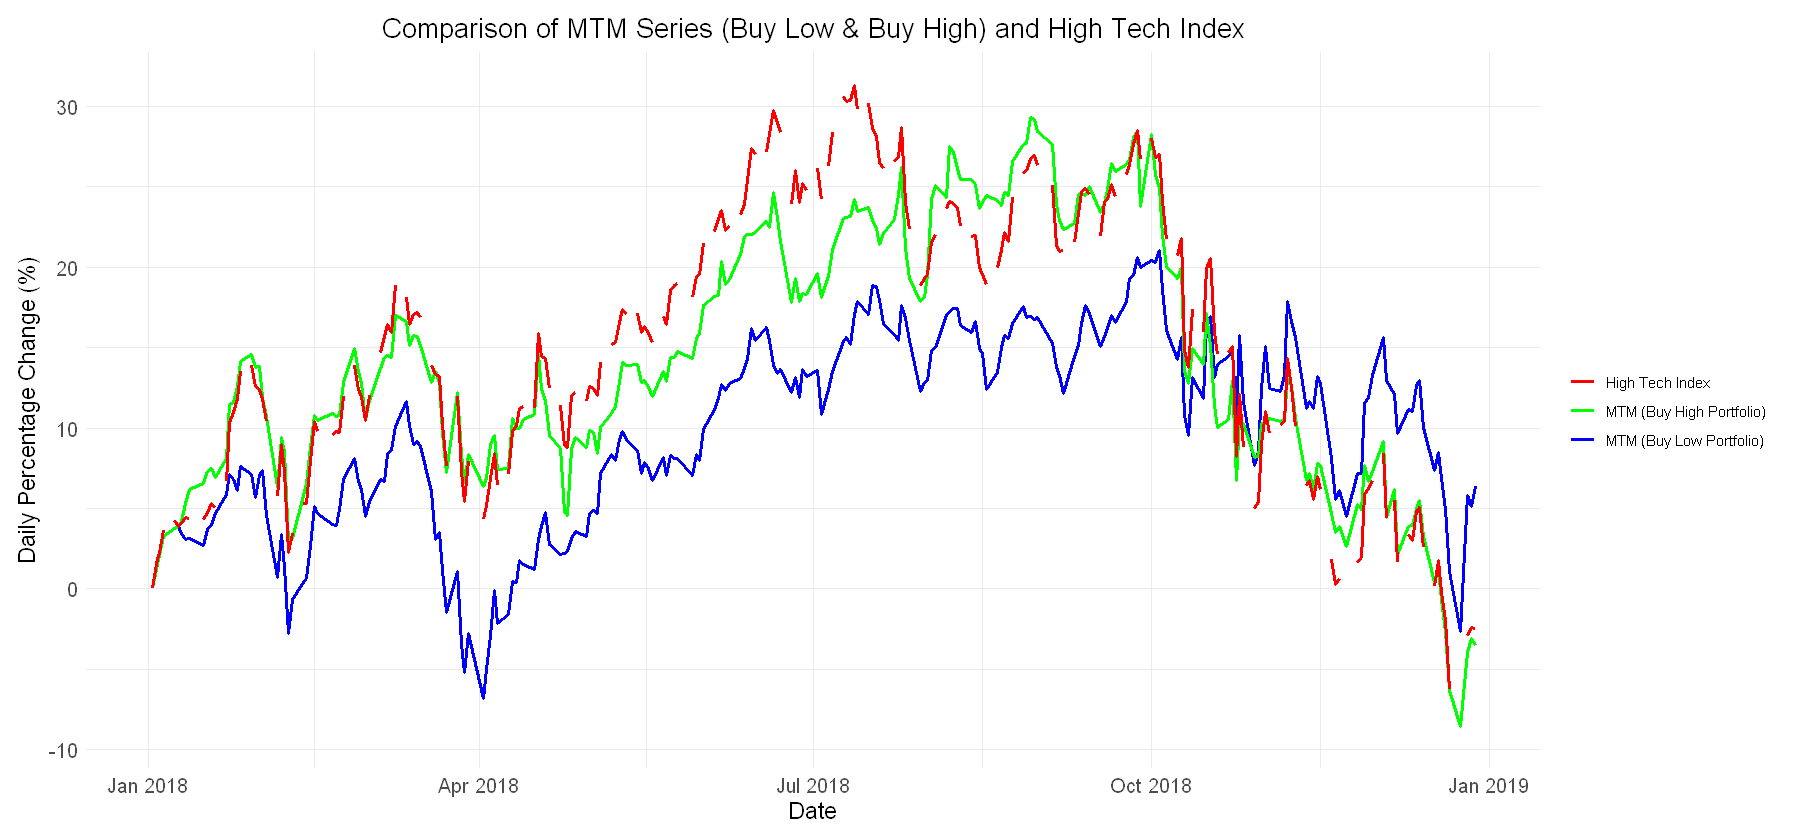

In [47]:
# Step 1: Create the High Tech Index (daily average of the 10 stock "Close" prices)
universe$high_tech_index = rowMeans(universe[, paste0(universe_tickers, "_Close")], na.rm = TRUE)

# Step 2: Calculate the daily percentage change with respect to Jan 02 2018 for buy_low, buy_high, and high tech index
mtm_initial_buy_low = portfolio_value_buy_low$MTM[portfolio_value_buy_low$Date == "2018-01-02"]
mtm_initial_buy_high = portfolio_value_buy_high$MTM[portfolio_value_buy_high$Date == "2018-01-02"]
index_initial = universe$high_tech_index[universe$Date == "2018-01-02"]

# Daily percentage change for MTM (buy_low strategy), MTM (buy_high strategy), and high tech index
portfolio_value_buy_low$MTM_pct_change = (portfolio_value_buy_low$MTM / mtm_initial_buy_low - 1) * 100
portfolio_value_buy_high$MTM_pct_change = (portfolio_value_buy_high$MTM / mtm_initial_buy_high - 1) * 100
universe$index_pct_change = (universe$high_tech_index / index_initial - 1) * 100

# Step 3: Plot the comparison of MTM (buy_low), MTM (buy_high), and the high tech index
# Create the plot with a larger size displayed inline
# Set plot width and height
options(repr.plot.width = 15, repr.plot.height = 7)  # Adjust this as needed for the desired aspect ratio

# Now plot the graph
ggplot(data = portfolio_value_buy_low, aes(x = Date)) +
  geom_line(aes(y = MTM_pct_change, color = "MTM (Buy Low Portfolio)"), linewidth = 1) +
  geom_line(data = portfolio_value_buy_high, aes(y = MTM_pct_change, color = "MTM (Buy High Portfolio)"), linewidth = 1) +
  geom_line(data = universe, aes(y = index_pct_change, color = "High Tech Index"), linewidth = 1) +
  labs(title = "Comparison of MTM Series (Buy Low & Buy High) and High Tech Index",
       y = "Daily Percentage Change (%)",
       x = "Date") +
  scale_color_manual(values = c("MTM (Buy Low Portfolio)" = "blue", 
                                "MTM (Buy High Portfolio)" = "green", 
                                "High Tech Index" = "red")) +
  theme_minimal() +
  theme(legend.title = element_blank(),
        plot.title = element_text(size = 16), 
        axis.title = element_text(size = 14), 
        axis.text = element_text(size = 12)) +
  theme(plot.margin = margin(10, 10, 10, 10)) +
  theme(plot.title = element_text(hjust = 0.5))  # Center-align the title

## Currency comparison: USD and JPY

The course-defined reference series is converted using daily USD/JPY closing rates. Comparing rebased USD and JPY series illustrates how exchange-rate movement changes returns from a yen-denominated perspective.


In [48]:
# Step 1: Load USD/JPY historical data

usdjpy_data = read.csv("data/raw/usdjpy.csv")
usdjpy_data

Date,Open,High,Low,Close,Adj.Close,Volume
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
31-Dec-18,110.324,110.468,109.659,110.330,110.330,-
28-Dec-18,110.860,110.930,110.222,110.855,110.855,-
27-Dec-18,111.221,111.222,110.653,111.206,111.206,-
26-Dec-18,110.431,110.698,110.286,110.402,110.402,-
25-Dec-18,110.314,110.344,109.991,110.311,110.311,-
24-Dec-18,111.100,111.140,110.267,111.054,111.054,-
21-Dec-18,111.198,111.450,110.939,111.171,111.171,-
20-Dec-18,112.422,112.599,111.331,112.410,112.410,-
19-Dec-18,112.497,112.584,112.133,112.524,112.524,-


In [49]:
# Ensure the Date columns are properly formatted
usdjpy_data$Date = as.Date(usdjpy_data$Date, format = "%d-%b-%y")  # Convert to Date format

# Step 2: Ensure 'universe' dataframe has the correct Date format
universe$Date = as.Date(universe$Date)

# Step 3: Merge the USD/JPY data with the universe dataframe based on Date
# Merge USD/JPY data into the universe dataframe
universe = merge(universe, usdjpy_data[, c("Date", "Close")], by = "Date", all.x = TRUE)


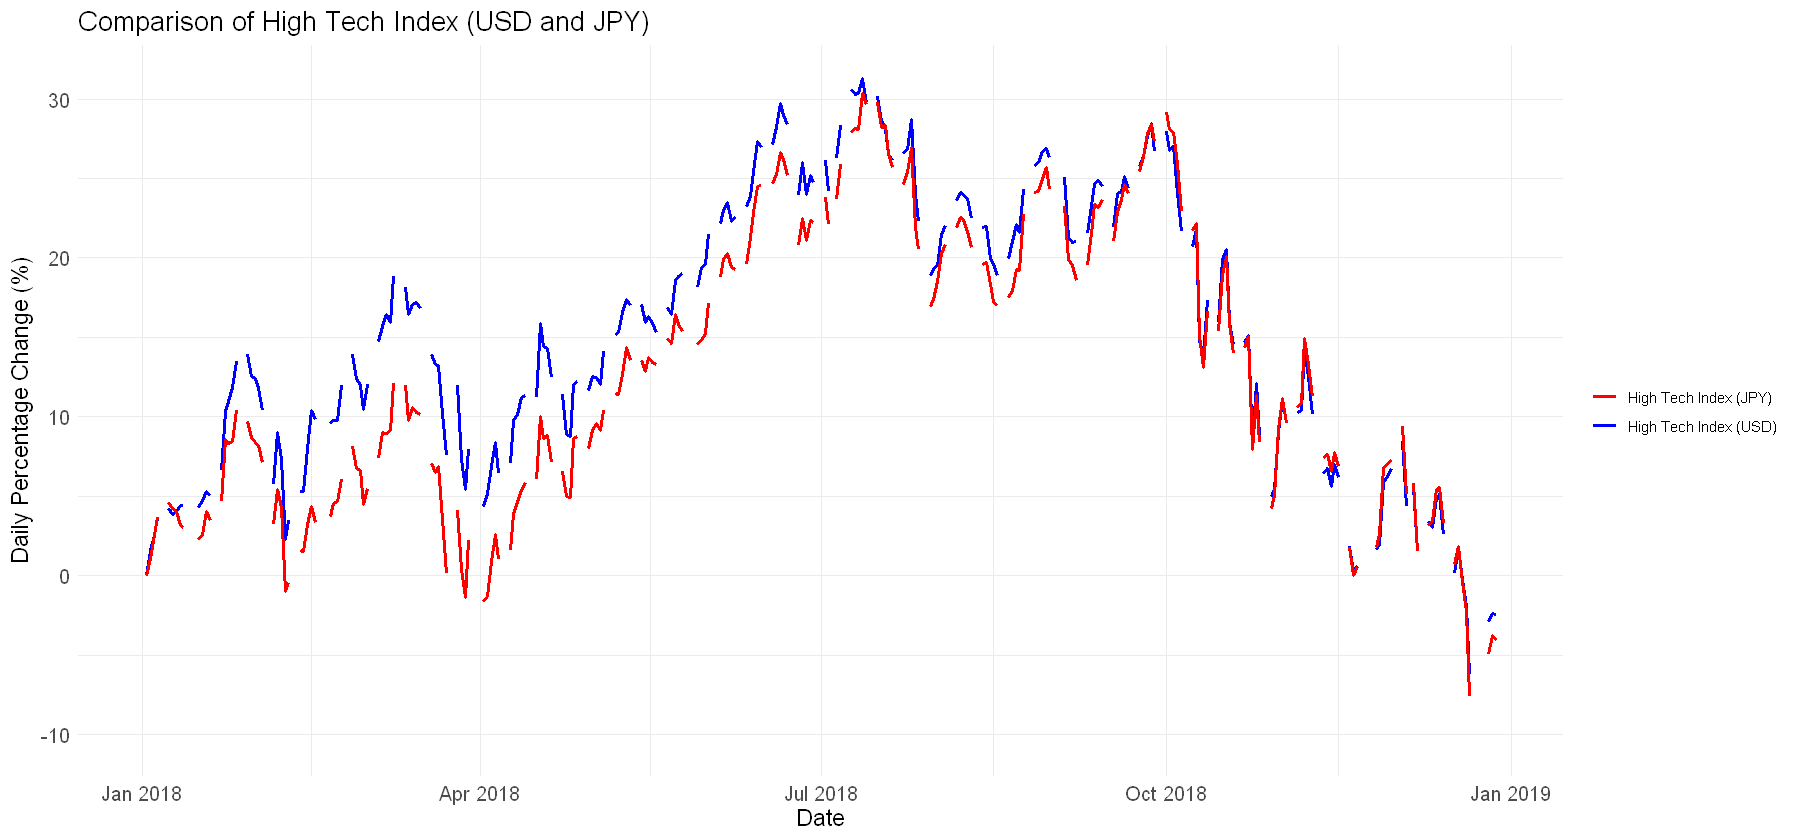

In [50]:
# Step 4: Convert High Tech Index from USD to JPY using the "Close" rate
# Add the new column for High Tech Index in JPY to the universe dataframe
universe$high_tech_index_JPY = universe$high_tech_index * universe$Close

# Step 5: Calculate daily percentage change for the High Tech Index in USD and JPY
# Initial values on 2018-01-02
index_initial_usd = universe$high_tech_index[universe$Date == "2018-01-02"]
index_initial_jpy = universe$high_tech_index_JPY[universe$Date == "2018-01-02"]

# Daily percentage change for High Tech Index (USD and JPY)
universe$index_pct_change_usd = (universe$high_tech_index / index_initial_usd - 1) * 100
universe$index_pct_change_jpy = (universe$high_tech_index_JPY / index_initial_jpy - 1) * 100

# Step 6: Plot the comparison of High Tech Index in USD and JPY
ggplot(data = universe, aes(x = Date)) +
  geom_line(aes(y = index_pct_change_usd, color = "High Tech Index (USD)"), linewidth = 1) +
  geom_line(aes(y = index_pct_change_jpy, color = "High Tech Index (JPY)"), linewidth = 1) +
  labs(title = "Comparison of High Tech Index (USD and JPY)",
       y = "Daily Percentage Change (%)",
       x = "Date") +
  scale_color_manual(values = c("High Tech Index (USD)" = "blue", 
                                "High Tech Index (JPY)" = "red")) +
  theme_minimal() +
  theme(legend.title = element_blank(),
        plot.title = element_text(size = 16), 
        axis.title = element_text(size = 14), 
        axis.text = element_text(size = 12))

## In-sample rebalancing-frequency comparison

The analysis evaluates intervals from 1 through 250 business days and ranks them by ending portfolio value on December 28, 2018, the final equity-market observation in the dataset. This is a retrospective sensitivity analysis—not out-of-sample optimization.


In [79]:
# Step 1: Define the maximum rebalance interval
number_business_days = length(universe$Date[!is.na(universe$IBM_Close)])
cat("Number of business days in the year:", number_business_days, "\n")

# Max rebalance interval
max_rebalance_interval = number_business_days
cat("Max frequency to rebalance per year (make equal to number of business days):", max_rebalance_interval, "\n")

Number of business days in the year: 250 
Max frequency to rebalance per year (make equal to number of business days): 250 


In [80]:
# Step 2: Initialize a dataframe to store MTM results for both strategies
results_df = data.frame(
  rebalance_interval = integer(),
  strategy = character(),
  final_MTM = numeric(),
  stringsAsFactors = FALSE
)

# Step 3: Function to track MTM and rebalance at different intervals
find_optimal_rebalance_frequency = function(universe, initial_portfolio, strategy) {
  for (n in 1:max_rebalance_interval) {
    # Apply the rebalance strategy for each interval
    portfolio_value = track_portfolio_daily_with_rebalance(universe, initial_portfolio, n = n, strategy = strategy, print_dividends = FALSE)
    
    # Get the final MTM on 12/31/2018
    final_MTM = portfolio_value$MTM[portfolio_value$Date == "2018-12-28"]
    
    # Store the results in the dataframe
    results_df <<- rbind(results_df, data.frame(rebalance_interval = n, 
                                                strategy = strategy, 
                                                final_MTM = final_MTM))
  }
}

# Step 4: Run the function for both buy_low and buy_high strategies
find_optimal_rebalance_frequency(universe, initial_portfolio, strategy = "buy_low")
find_optimal_rebalance_frequency(universe, initial_portfolio, strategy = "buy_high")

# Step 5: Find the optimal rebalance interval for both strategies
optimal_buy_low = results_df %>%
  filter(strategy == "buy_low") %>%
  arrange(desc(final_MTM)) %>%
  slice(1)

optimal_buy_high = results_df %>%
  filter(strategy == "buy_high") %>%
  arrange(desc(final_MTM)) %>%
  slice(1)

# Display the results
cat("Optimal rebalance interval for buy low strategy:", optimal_buy_low$rebalance_interval, 
    "with final MTM of:", optimal_buy_low$final_MTM, "\n")

cat("Optimal rebalance interval for buy high strategy:", optimal_buy_high$rebalance_interval, 
    "with final MTM of:", optimal_buy_high$final_MTM, "\n")


Optimal rebalance interval for buy low strategy: 194 with final MTM of: 5926309 
Optimal rebalance interval for buy high strategy: 29 with final MTM of: 5420556 


In [81]:
# Top 3 results for buy_low strategy
top_buy_low = results_df %>%
  filter(strategy == "buy_low") %>%
  arrange(desc(final_MTM)) %>%
  head(5)

cat("Top 5 results for buy_low strategy:\n")
print(top_buy_low)

# Top 5 results for buy_high strategy
top_buy_high = results_df %>%
  filter(strategy == "buy_high") %>%
  arrange(desc(final_MTM)) %>%
  head(5)

cat("\nTop 5 results for buy_high strategy:\n")
print(top_buy_high)

Top 5 results for buy_low strategy:
  rebalance_interval strategy final_MTM
1                194  buy_low   5926309
2                 58  buy_low   5904111
3                193  buy_low   5887041
4                 60  buy_low   5879885
5                172  buy_low   5855248

Top 5 results for buy_high strategy:
  rebalance_interval strategy final_MTM
1                 29 buy_high   5420556
2                 11 buy_high   5414464
3                 12 buy_high   5410277
4                  1 buy_high   5275014
5                 80 buy_high   5225538


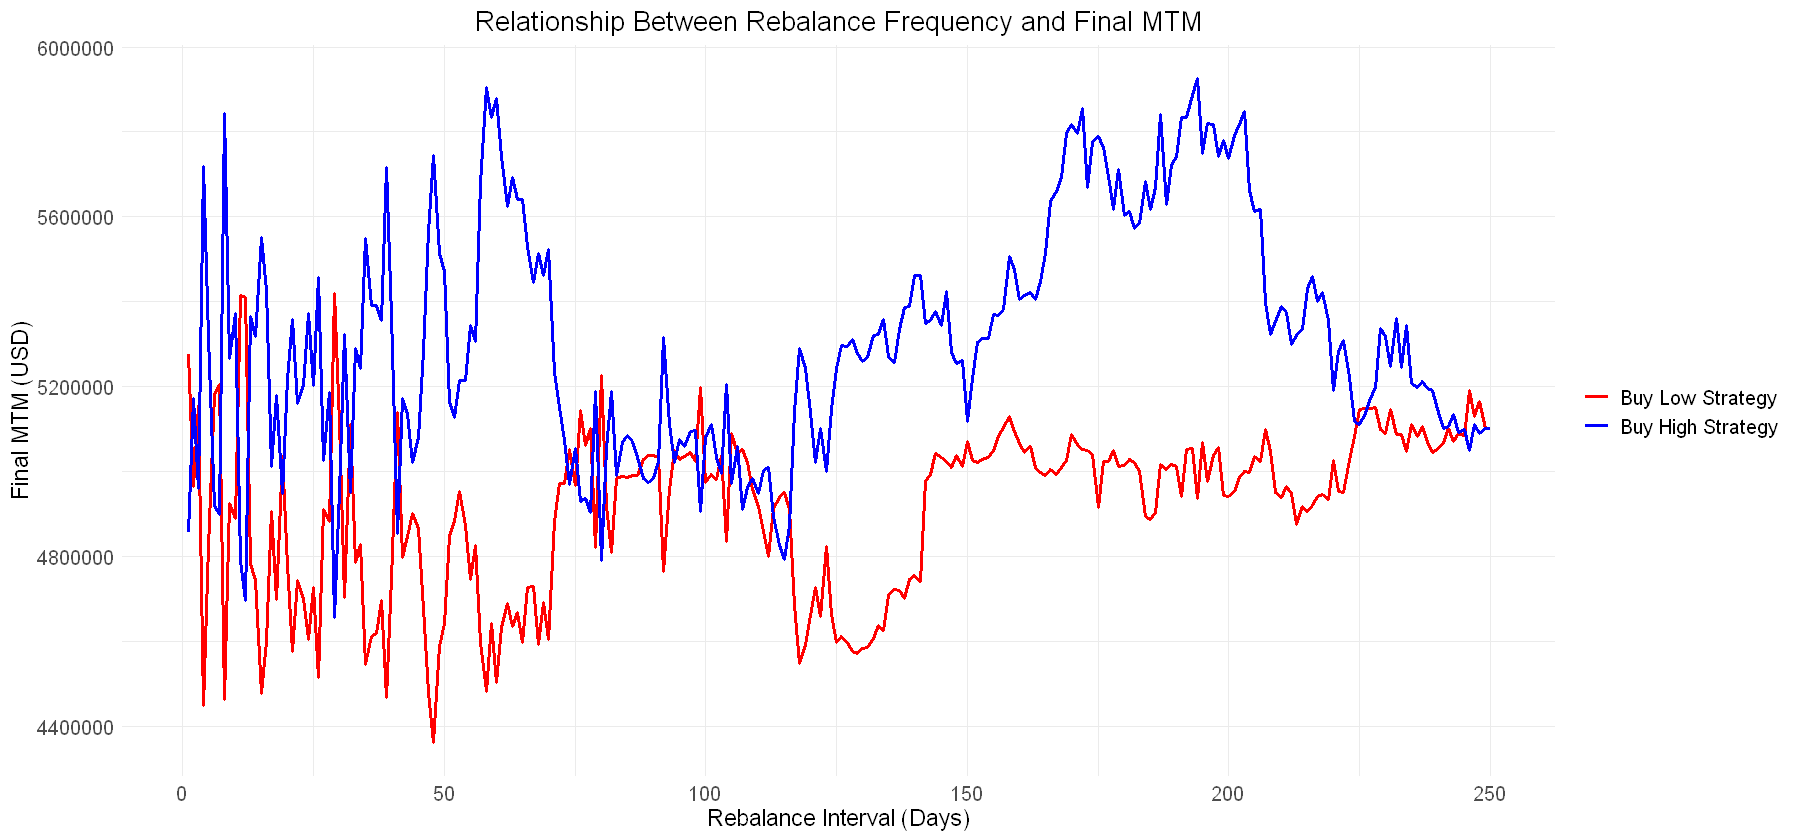

In [82]:
# Plot the relationship between rebalance frequency and MTM for both strategies
ggplot(data = results_df, aes(x = rebalance_interval, y = final_MTM, color = strategy)) +
  geom_line(linewidth = 1) +
  labs(title = "Relationship Between Rebalance Frequency and Final MTM",
       x = "Rebalance Interval (Days)",
       y = "Final MTM (USD)") +
  scale_color_manual(values = c("buy_low" = "blue", "buy_high" = "red"),
                     labels = c("Buy Low Strategy", "Buy High Strategy")) +
  theme_minimal() +
  theme(plot.title = element_text(size = 16, hjust = 0.5),
        axis.title.x = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        axis.text = element_text(size = 12),
        legend.title = element_blank(),
        legend.text = element_text(size = 12))

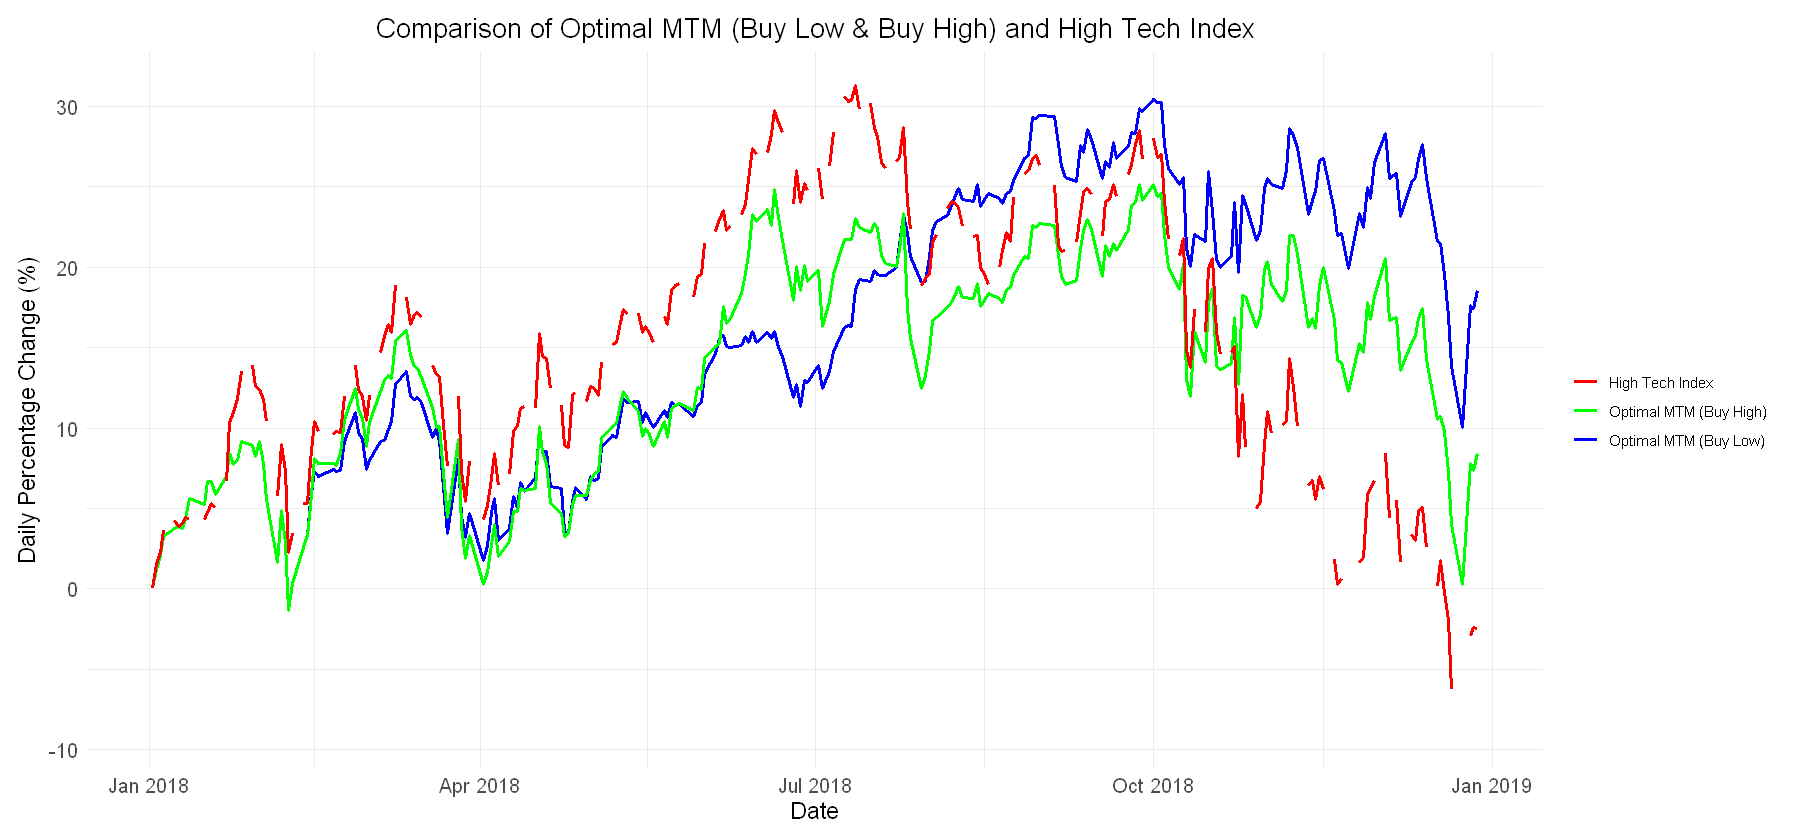

In [83]:
# Assuming `optimal_buy_low$rebalance_interval` and `optimal_buy_high$rebalance_interval` contain the optimal intervals

# Step 1: Run the optimal rebalance for both buy_low and buy_high strategies
optimal_portfolio_buy_low = track_portfolio_daily_with_rebalance(universe, initial_portfolio, 
                                                                 n = optimal_buy_low$rebalance_interval, 
                                                                 strategy = "buy_low",
                                                                 print_dividends = FALSE)

optimal_portfolio_buy_high = track_portfolio_daily_with_rebalance(universe, initial_portfolio, 
                                                                  n = optimal_buy_high$rebalance_interval, 
                                                                  strategy = "buy_high",
                                                                 print_dividends = FALSE)

# Step 2: Calculate the daily percentage change with respect to Jan 02 2018 for both strategies and the High Tech Index
# Initial values on 2018-01-02
mtm_initial_optimal_buy_low = optimal_portfolio_buy_low$MTM[optimal_portfolio_buy_low$Date == "2018-01-02"]
mtm_initial_optimal_buy_high = optimal_portfolio_buy_high$MTM[optimal_portfolio_buy_high$Date == "2018-01-02"]
index_initial = universe$high_tech_index[universe$Date == "2018-01-02"]

# Daily percentage change for MTM (optimal buy_low strategy), MTM (optimal buy_high strategy), and High Tech Index
optimal_portfolio_buy_low$MTM_pct_change = (optimal_portfolio_buy_low$MTM / mtm_initial_optimal_buy_low - 1) * 100
optimal_portfolio_buy_high$MTM_pct_change = (optimal_portfolio_buy_high$MTM / mtm_initial_optimal_buy_high - 1) * 100
universe$index_pct_change = (universe$high_tech_index / index_initial - 1) * 100

# Step 3: Plot the comparison of optimal MTM (buy_low), optimal MTM (buy_high), and the High Tech Index
# Adjust the plot size for better visualization
options(repr.plot.width = 15, repr.plot.height = 7)

# Create the plot
ggplot(data = optimal_portfolio_buy_low, aes(x = Date)) +
  geom_line(aes(y = MTM_pct_change, color = "Optimal MTM (Buy Low)"), linewidth = 1) +
  geom_line(data = optimal_portfolio_buy_high, aes(y = MTM_pct_change, color = "Optimal MTM (Buy High)"), linewidth = 1) +
  geom_line(data = universe, aes(y = index_pct_change, color = "High Tech Index"), linewidth = 1) +
  labs(title = "Comparison of Optimal MTM (Buy Low & Buy High) and High Tech Index",
       y = "Daily Percentage Change (%)",
       x = "Date") +
  scale_color_manual(values = c("Optimal MTM (Buy Low)" = "blue", 
                                "Optimal MTM (Buy High)" = "green", 
                                "High Tech Index" = "red")) +
  theme_minimal() +
  theme(legend.title = element_blank(),
        plot.title = element_text(size = 16), 
        axis.title = element_text(size = 14), 
        axis.text = element_text(size = 12)) +
  theme(plot.margin = margin(10, 10, 10, 10)) +
  theme(plot.title = element_text(hjust = 0.5))  # Center-align the title


# Results summary

- **Best in-sample contrarian interval**: 194 days with a final MTM of \$5,926,309.
- **Best in-sample momentum interval**: 29 days with a final MTM of \$5,420,556.

## Top 5 Results for Buy Low Strategy:

| Rebalance Interval | Final MTM   |
|:-------------------|:------------|
| 194                | \$5,926,309 |
| 58                 | \$5,904,111 |
| 193                | \$5,887,041 |
| 60                 | \$5,879,885 |
| 172                | \$5,855,248 |

## Top 5 Results for Buy High Strategy:

| Rebalance Interval | Final MTM   |
|:-------------------|:------------|
| 29                 | \$5,420,556 |
| 11                 | \$5,414,464 |
| 12                 | \$5,410,277 |
| 1                  | \$5,275,014 |
| 80                 | \$5,225,538 |


## Interpretation and limitations

The rebalancing-frequency search is **in-sample**: intervals are selected and evaluated on the same 2018 observations. The highest ending values therefore describe retrospective fit, not expected future performance. The simulation also excludes trading costs, spreads, slippage, taxes, and cash interest. Its ten-stock universe is narrow, and its price-average benchmark is not a conventional equal-weighted total-return index. Dividend values are inferred from closing and adjusted-closing prices rather than sourced from a dedicated corporate-actions dataset. These results are educational and are not investment advice.
